# kNN Model

### We use a kNN model which is a supervised learning classifier that uses proximity to make classifications. An observation is classified based on those around it.  

In [ ]:
# kNN model here
# test out diff hyperparameters like k, distance metric, weights
# try out diff distance metrics to do 

import pandas as pd 
import joblib

X_train = pd.read_csv('../data/X_train_scaled.csv')
X_test = pd.read_csv('../data/X_test_scaled.csv')
Y_train = pd.read_csv('../data/Y_train.csv') 
Y_test = pd.read_csv('../data/Y_test.csv')

# since these are loaded as DataFrames convert into 1D arrays 
y_train = Y_train.squeeze()
y_test = Y_test.squeeze()

# we will also load in our label encoder
label_encoder = joblib.load(
    '../data/label_encoder.pkl'
)

Now we'll train a baseline model with k = 5

In [7]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

### Metrics and Visualization
And let's get some metrics...
We'll use macro because we have multiple genres that aren't perfectly balanced and macro averaging treats them all equaly

Accuracy: 0.434971098265896
Precision: 0.42951198622328224
Recall: 0.42298731301713427
F1: 0.4189112897011537


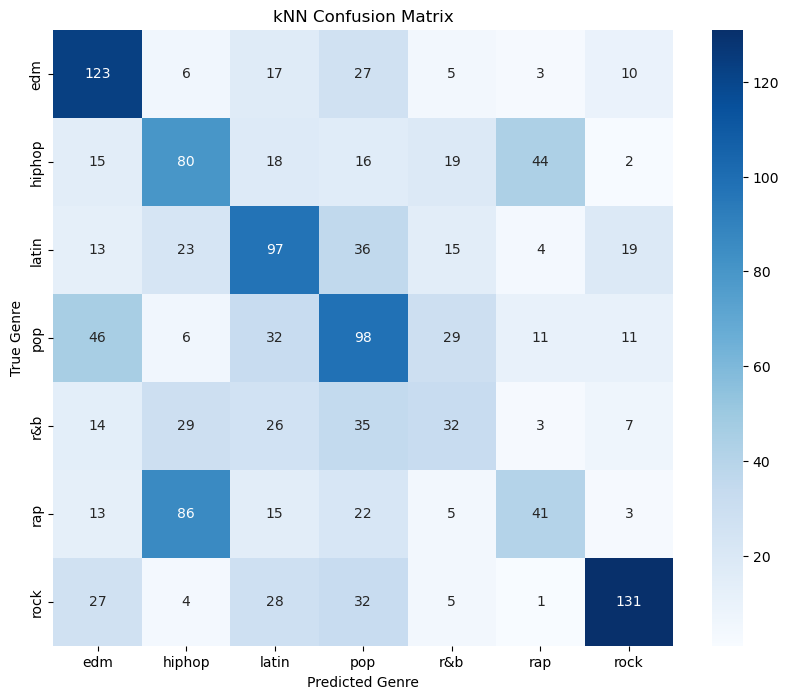

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

genre_labels = label_encoder.classes_

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred, average='macro')

recall = recall_score(y_test, y_pred, average='macro')

f1 = f1_score(y_test, y_pred, average='macro')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=genre_labels,
    yticklabels=genre_labels
)

plt.title("kNN Confusion Matrix")
plt.xlabel("Predicted Genre")
plt.ylabel("True Genre")

plt.show()




Now let's try a couple of different k values...and plot the differences 

k=1, accuracy=0.3468208092485549
k=3, accuracy=0.4060693641618497
k=5, accuracy=0.434971098265896
k=7, accuracy=0.4624277456647399
k=9, accuracy=0.46315028901734107
k=11, accuracy=0.4841040462427746
k=15, accuracy=0.4877167630057804
k=20, accuracy=0.4920520231213873
k=30, accuracy=0.5021676300578035


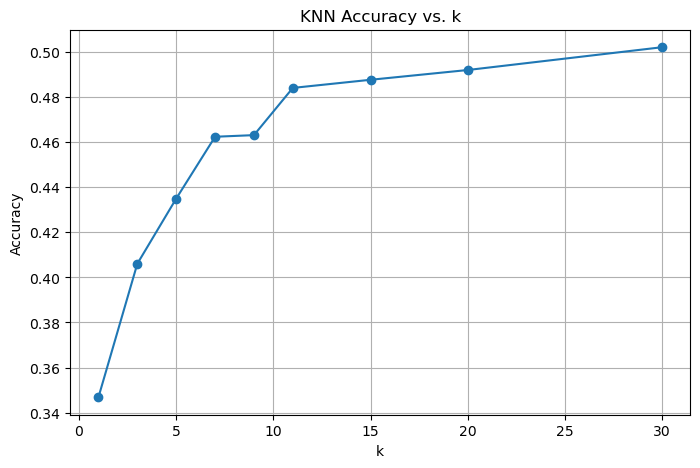

In [16]:
k_values = [1, 3, 5, 7, 9, 11, 15, 20, 30]

accuracies = []

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train, y_train)
    
    y_pred = knn.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

    print(f"k={k}, accuracy={acc}")

plt.figure(figsize=(8,5))
plt.plot(k_values, accuracies, marker='o')

plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs. k")
plt.grid(True)
plt.show()